# Overview

Although diabetes is broadly classified as type 1 and type 2 diabetes, type 2 diabetes is known to be heterogeneous. Finer classifications of diabetes could aid in the personalization of diabetes treatment. 

Ahlqvist et al. recently identified 5 subtypes of diabetes with different risks of diabetic complications using:

1. glutamate decarboxylase antibody status
2. age at diagnoses
3. body mass index
4. HbA1c
5. homeostatic model assessment 2 estimates of beta-cell function
6. homeostatic model assessment 2 estimates of insulin resistance

Glutamate decarboxylase antibody status was not measured in recent NHANES surveys.

**Objective:** Using records from NHANES, reproduce the 5 subtypes of diabetes identified by [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

# Environment setup

Import functional packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Import cleaned and joined dataset.

In [2]:
export_dir = "../exports/NHANES/"

data_path = export_dir + "nhanes_clustering_features.csv"
data = pd.read_csv(data_path)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1714 entries, 0 to 1713
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEQN               1714 non-null   int64  
 1   cycle              1714 non-null   object 
 2   DIQ010             1714 non-null   object 
 3   LBXGH              1714 non-null   float64
 4   BMXBMI             1714 non-null   float64
 5   RIDAGEYR           1714 non-null   int64  
 6   LBDINSI            1714 non-null   float64
 7   LBDGLUSI           1714 non-null   float64
 8   homa1_cpeptide_b   1714 non-null   float64
 9   homa1_cpeptide_ir  1714 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 134.0+ KB


# Data cleaning

Remove rows with missing data in the 5 features for clustering.

In [3]:
clustering_features = ["LBXGH", "BMXBMI", "RIDAGEYR", "homa1_cpeptide_b", "homa1_cpeptide_ir"]

data_no_na = data.dropna(subset = clustering_features,
                           axis = 0)

Remove participants with previously medically diagnosed diabetes.

In [4]:
data_no_na = data_no_na[data_no_na["DIQ010"] == "Yes"].copy()

Confirm data type and check for misssing values.

In [5]:
data_no_na[clustering_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1225 entries, 0 to 1712
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LBXGH              1225 non-null   float64
 1   BMXBMI             1225 non-null   float64
 2   RIDAGEYR           1225 non-null   int64  
 3   homa1_cpeptide_b   1225 non-null   float64
 4   homa1_cpeptide_ir  1225 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 57.4 KB


Remove outlier. Outliers were defined as values greater than 5 standard deviations from the mean same as used by [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

Defined function to remove outliers based on number of standard deviations from mean. 

In [6]:
# remove outliers by z score
def remove_outlier(df, feature, distance):
    upper = []
    lower = []
    
    # find upper and lower bounds that defines an outlier
    for f in feature:
        upper.append(df[f].mean() + distance * df[f].std())
        lower.append(df[f].mean() - distance * df[f].std())
    
    # subset df to only values within the outlier boundaries
    for i in range(len(upper)):
        df = df[(df[feature[i]] < upper[i]) & (df[feature[i]] > lower[i])]
    return df

In [7]:
# remove outliers outpatient data and print number of rows removed
data_cleaned = remove_outlier(data_no_na, clustering_features, 5)
rows_removed = data_no_na.shape[0] - data_cleaned.shape[0]
print(f"{rows_removed} respondents were removed as outliers.")

4 respondents were removed as outliers.


In [8]:
print(f"Number of respondents: {data_cleaned.shape[0]}")


Number of respondents: 1221


Since GAD autoantibodies were not measured, the SAID cluster was impossible to identify. However, since SAID largely represents type 1 diabetes and generally only accounts for a small percentage of the clusters, it was not relevant for this type 2 diabetes focused study.

Check that feature values look reasonable.

In [9]:
data_cleaned[clustering_features].describe()

,LBXGH,BMXBMI,RIDAGEYR,homa1_cpeptide_b,homa1_cpeptide_ir
count,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000
mean,7.422031,32.551433,62.441441,30.826391,1.839545
std,1.719673,7.458435,12.065975,25.152882,1.029216
min,4.400000,17.000000,20.000000,2.724169,0.426212
25%,6.200000,27.400000,55.000000,15.054229,1.099432
50%,6.900000,31.200000,63.000000,24.289257,1.572342
75%,8.100000,36.200000,72.000000,38.166634,2.338506
max,15.400000,66.500000,80.000000,253.275802,6.942967


# Clustering

Import the packages for scaling and clustering

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering

Features were scaled same as [Lu et al.](https://doi.org/10.1210/clinem/dgae516).

In [11]:
x = data_cleaned[clustering_features]

x_scaled = MinMaxScaler().fit_transform(x)

Visualize clustering hierarchy. Dendrogram function was taken from the sklearn [example page](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html).

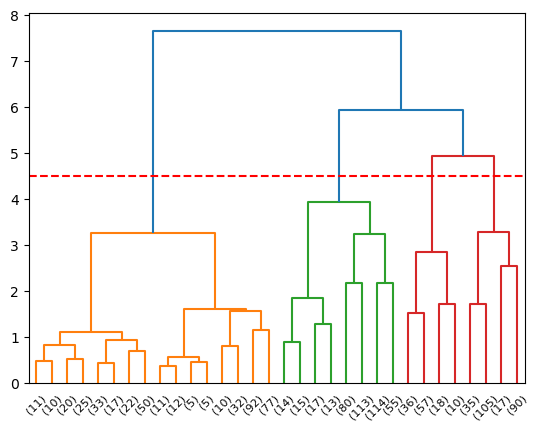

In [12]:
from scipy.cluster.hierarchy import dendrogram

clustering = AgglomerativeClustering(n_clusters = None, compute_distances = True, distance_threshold = 0).fit(x_scaled)

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)
    
plot_dendrogram(clustering, truncate_mode="level", p=4)

# label approximate threshold with 5 clusters
plt.axhline(y=4.5, color='r', linestyle='--');

Also visualized silhouette scores for different number of clusters.

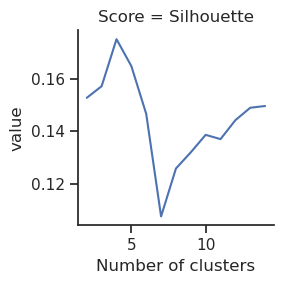

In [13]:
from sklearn.metrics import silhouette_score
# check silhouette
sil = list()
sns.set(font_scale = 1, style = "ticks")

# calculate inertia and silhouette scores for 2 to 14 clusters
for i in range(2, 15):
    clustering = AgglomerativeClustering(n_clusters = i).fit(x_scaled)
    #inertia.append(clustering.inertia_)
    sil.append(silhouette_score(x_scaled, clustering.labels_))

# organize score for graphing
outpatient_scores = pd.DataFrame({"Number of clusters": range(2, 15),
                              "Silhouette" : sil})
outpatient_scores = outpatient_scores.melt(id_vars = "Number of clusters")
outpatient_scores = outpatient_scores.rename(columns = {"variable": "Score"})

# visualize
g = sns.FacetGrid(outpatient_scores, col = "Score", sharey = False)
g.map(sns.lineplot, "Number of clusters", "value");

Re-cluster with the same number of expected clusters as [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2) minus the SAID cluster.

In [14]:
clustering = AgglomerativeClustering(n_clusters = 4).fit(x_scaled)

In [15]:
clustering.get_params(deep=True)

{'compute_distances': False,
 'compute_full_tree': 'auto',
 'connectivity': None,
 'distance_threshold': None,
 'linkage': 'ward',
 'memory': None,
 'metric': 'euclidean',
 'n_clusters': 4}

Assign the cluster labels back to the cleaned data.

In [16]:
data_cleaned["clusters"] = clustering.labels_.tolist()

Visualize the cluster features.

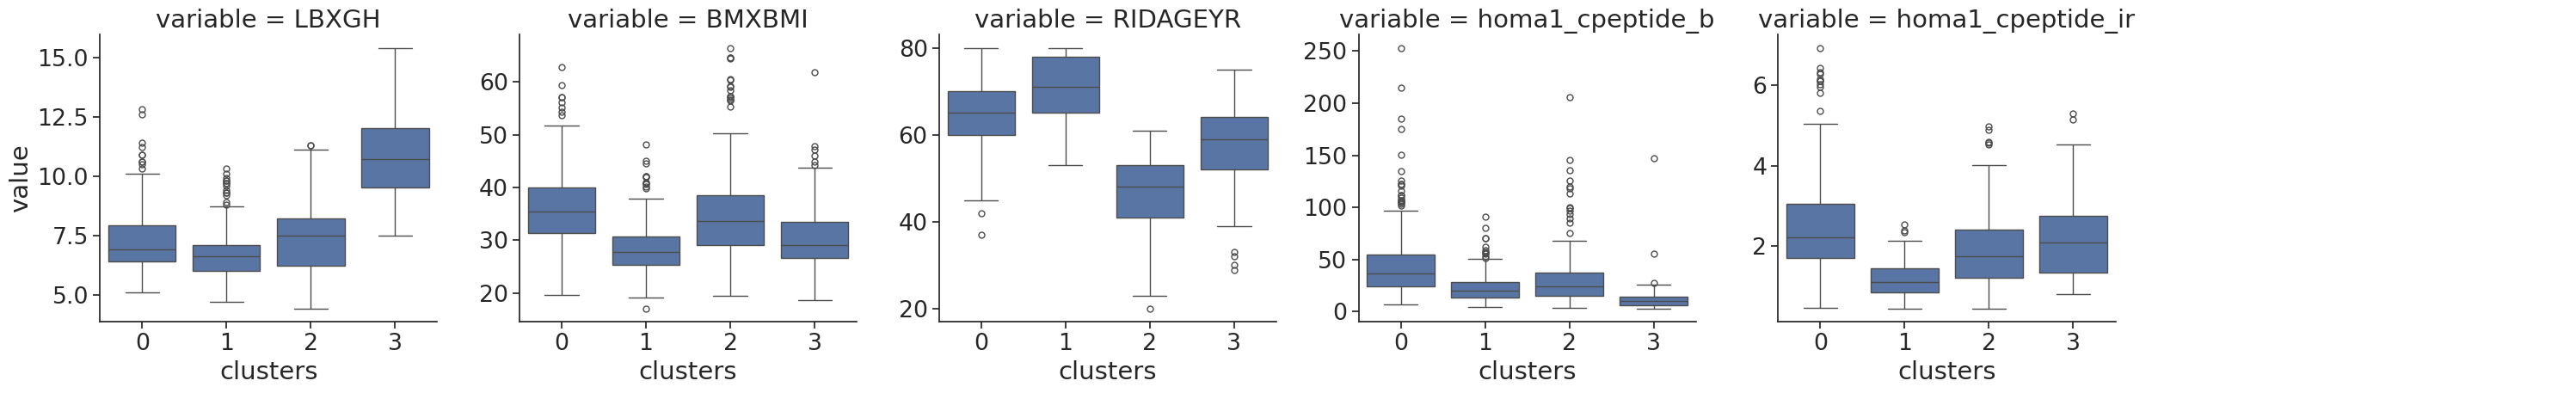

In [17]:
# convert data to long form for graphing
data_long = data_cleaned.melt(id_vars = "clusters", 
                                                   value_vars = clustering_features)

# set plot size
sns.set(font_scale = 1.75, style = "ticks")

# plot features by cluster
sns.catplot(data = data_long, 
            x = "clusters", 
            y = "value", 
            col = "variable", 
            col_wrap = 6, 
            kind = "box", 
            sharey = False);

Assign cluster labels from [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2) based on features.

In [18]:
remap = {0 : "SIRD", 
         1 : "MARD",
         2 : "MOD",
         3 : "SIDD"}

data_cleaned["hier_clusters"] = data_cleaned["clusters"].map(remap)
print("Number of outpatients in each cluster:")
data_cleaned["hier_clusters"].value_counts()

Number of outpatients in each cluster:


hier_clusters
MARD    432
SIRD    421
MOD     247
SIDD    121
Name: count, dtype: int64

Plot features again with cluster assignments and similar color scheme as Ahlqvist et al.

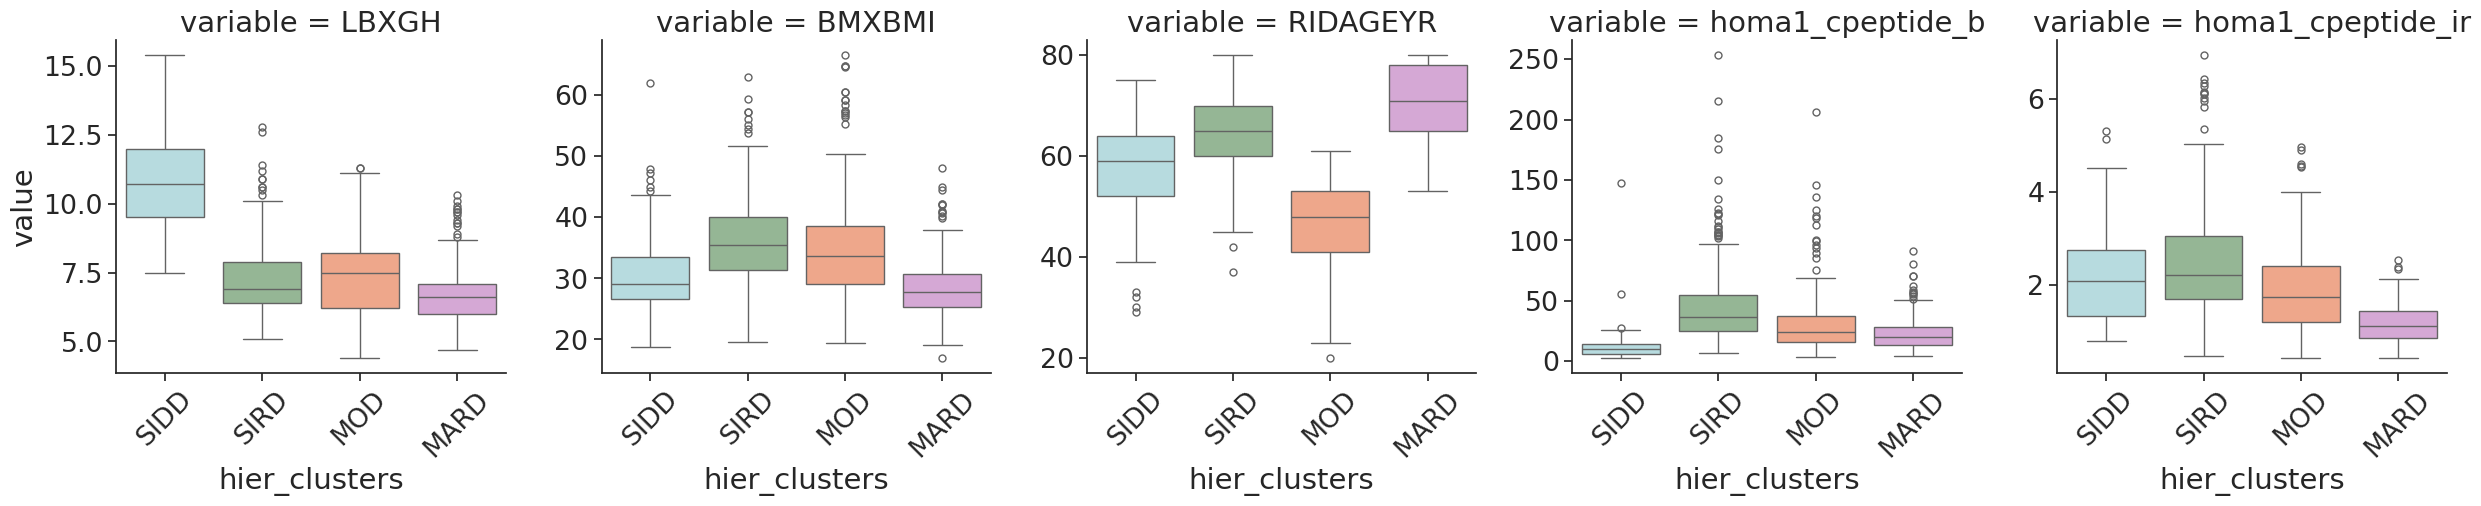

In [19]:
# convert data to long form for graphing
data_long = data_cleaned.melt(id_vars = "hier_clusters", 
                                                   value_vars = clustering_features)

# plot features by cluster
color = ["powderblue", "darkseagreen", "lightsalmon", "plum"]
order = ["SIDD", "SIRD", "MOD", "MARD"]

sns.catplot(data = data_long, 
            x = "hier_clusters", 
            y = "value", 
            col = "variable", 
            col_wrap = 5, 
            kind = "box", 
            sharey = False,
            order = order,
            hue = "hier_clusters",
            palette = {key: value for key, value in zip(order, color)}
           ).set_xticklabels(labels = order, rotation = 45);

Distribution of cluster features from hierarchical clustering of NHANES respondents are similar to those previously reported in [Lu et al.](https://doi.org/10.1210/clinem/dgae516) for the University of Alabama at Birmingham except SIRD have higher BMI than MOD.

# Export clusters

In [20]:
import datetime
from watermark import watermark

# export cluster data
data_export = data_cleaned[["SEQN", "hier_clusters"]]
data_export.to_csv(export_dir + "nhanes_denovo_diagnosed_clusters.csv", index = False)

In [21]:
print(watermark())

Last updated: 2025-07-03T10:32:13.215660-05:00

Python implementation: CPython
Python version       : 3.12.6
IPython version      : 8.27.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 3.10.0-1160.24.1.el7.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 48
Architecture: 64bit

